# Spatial Coordinate Units & Radius Calibration

The NSCLC paper defines neighbourhoods as **50 um center-to-center radius** with a
median of **32 cells in 2D**.  
This notebook calibrates the coordinate units of `ad.obsm['spatial']` by finding the
radius (in coordinate units) that reproduces that median neighbour count.

**Strategy - inverted calibration**:
1. Sweep candidate radii; measure median neighbour count at each.
2. Interpolate to find the exact radius where median = 32.
3. Back-calculate implied um/unit; cross-check against NN cell-spacing.
4. Confirm visually and compute the full neighbour-count distribution.
5. Compute radius-COVET and compare to fixed-k COVET (k=35).

## Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q scarches SEACells faiss-gpu-cu12 scib-metrics

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.2/581.2 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 77.7 MB/s eta 0

In [3]:
%run /content/drive/MyDrive/codes/interpretable-prototype/notebooks/nb_setup.py

nb_setup done. Available: get_trainer, run_mc_task, fig_*, LAMBDA_PROTO_UMAP, LAMBDA_PROTO_UMAP_PRECON, LAMBDA_PARAM_UMAP, LAMBDA_RECON_ONLY, train_sure, eval_sure_task1/2/3
Configs: {'LAMBDA_PROTO_UMAP': {'lambda_umap': 1, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 0, 'lambda_proto_recon': 0.0, 'umap_similarity': 'proto'}, 'LAMBDA_PARAM_UMAP': {'lambda_umap': 1, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 0, 'lambda_proto_recon': 0.0, 'umap_similarity': 'embedding'}, 'LAMBDA_RECON_ONLY': {'lambda_umap': 0, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 1, 'lambda_proto_recon': 0.0}}


## Config

In [6]:
import os

DATA_PATH        = os.path.join(os.environ["DATA_DIR"], "spatial/NSCLC_3D_section_28.h5ad")
TARGET_RADIUS_UM = 50.0  # paper: 50 um center-to-center
TARGET_NEIGHBORS = 32    # paper: median 32 cells in 2D within 50 um

## Load data

In [7]:
import scanpy as sc
import numpy as np

ad = sc.read_h5ad(DATA_PATH)
print(ad)
print('obsm keys:', list(ad.obsm.keys()))

AnnData object with n_obs × n_vars = 58423 × 960
    obs: 'section', 'celltypes', 'niches_3D', 'niches_2D', 'fibroblast_subclusters', 'tumor_pseudotime_rank', 'EMT_niche'
    uns: 'EMT_niche_colors', 'celltypes_colors', 'fibroblast_subclusters_colors', 'log1p', 'niches_2D_colors', 'niches_3D_colors', 'pca'
    obsm: 'X_covet', 'X_pca', 'X_umap_2D_neighbourhoods', 'X_umap_3D_neighbourhoods', 'X_umap_SCT', 'spatial'
    varm: 'PCs'
    layers: 'SCT', 'counts'
obsm keys: ['X_covet', 'X_pca', 'X_umap_2D_neighbourhoods', 'X_umap_3D_neighbourhoods', 'X_umap_SCT', 'spatial']


## Step 1 — coordinate range & metadata

Check coordinate scale and whether `ad.uns` already stores pixel size.

In [8]:
spatial = ad.obsm['spatial'][:, :2].astype(float)

print('Coordinate ranges:')
print(f'  x: {spatial[:,0].min():.2f} – {spatial[:,0].max():.2f}  '
      f'(span {spatial[:,0].max() - spatial[:,0].min():.2f})')
print(f'  y: {spatial[:,1].min():.2f} – {spatial[:,1].max():.2f}  '
      f'(span {spatial[:,1].max() - spatial[:,1].min():.2f})')

# check uns for any pixel size metadata
pixel_size_keys = ['pixel_size', 'microns_per_pixel', 'um_per_pixel',
                   'resolution', 'pixel_size_um', 'scale']
found = {k: ad.uns[k] for k in pixel_size_keys if k in ad.uns}
if found:
    print('\nFound in ad.uns:', found)
else:
    print('\nNo pixel size metadata in ad.uns — will estimate empirically below.')

Coordinate ranges:
  x: 17.21 – 998.40  (span 981.19)
  y: -1000.00 – -8.75  (span 991.25)

No pixel size metadata in ad.uns — will estimate empirically below.


## Step 2 - nearest-neighbour distance (reference only)

We use the median NN distance as a **cross-check** after calibration, not as the
primary scale source. The cell-diameter assumption gave the wrong neighbour count.

In [9]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=2).fit(spatial)
dists, _ = nn.kneighbors(spatial)
nn_dists = dists[:, 1]
median_nn = float(np.median(nn_dists))
p25, p75  = np.percentile(nn_dists, [25, 75])
print(f"Nearest-neighbour distance (coordinate units):")
print(f"  median={median_nn:.3f}  p25={p25:.3f}  p75={p75:.3f}")
print("  (cross-check reference -- scale set by sweep below)")

Nearest-neighbour distance (coordinate units):
  median=2.235  p25=1.778  p75=2.893
  (cross-check reference -- scale set by sweep below)


## Step 3 - radius sweep: find radius where median neighbours = 32

Sweep candidate radii on a subsample, measure median neighbour count at each,
then interpolate to find the radius where median = TARGET_NEIGHBORS.
No cell-diameter assumption needed.

  'radius       '  'median_nbrs           '  'mean_nbrs         '
    3.00           2.0         1.8
    4.28           4.0         4.1
    5.55           6.0         7.1
    6.83          10.0        10.8
    8.10          13.0        15.2
    9.38          18.0        20.3
   10.66          23.0        26.0
   11.93          29.0        32.4
   13.21          35.0        39.4
   14.48          42.0        47.1
   15.76          50.0        55.5
   17.03          58.0        64.4
   18.31          67.0        74.0
   19.59          76.0        84.2
   20.86          86.0        95.1
   22.14          97.0       106.5
   23.41         108.0       118.6
   24.69         120.0       131.2
   25.97         132.0       144.6
   27.24         145.0       158.4
   28.52         159.0       172.9
   29.79         173.0       188.0
   31.07         188.0       203.7
   32.34         203.0       220.0
   33.62         219.0       236.8
   34.90         236.0       254.3
   36.17         253.0  

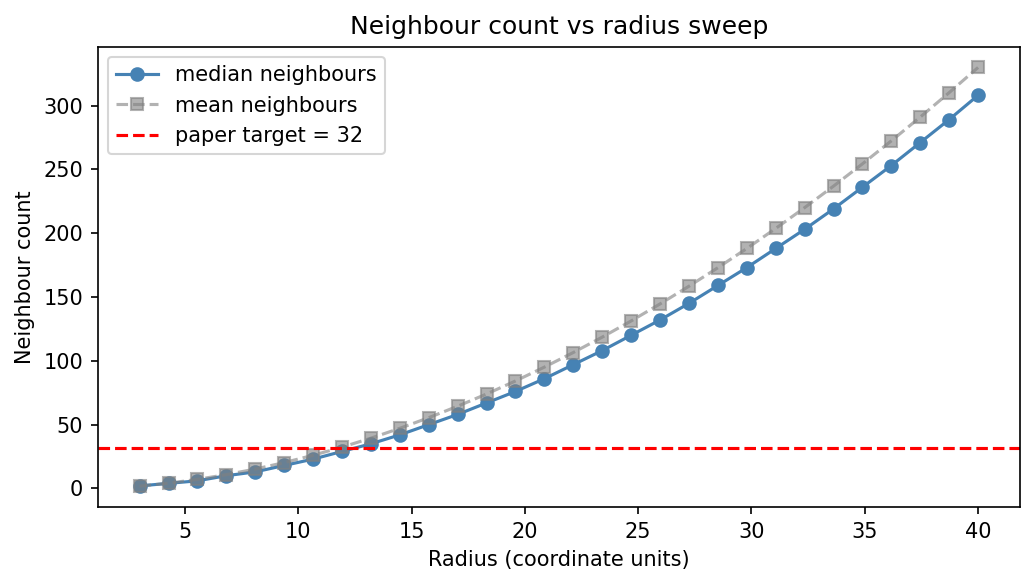

In [20]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
sub_idx = rng.choice(len(spatial), size=min(len(spatial), len(spatial)), replace=False)
spatial_sub = spatial[sub_idx]

candidate_radii = np.linspace(3, 40, 30)
median_counts = []
mean_counts   = []
nn_sweep = NearestNeighbors().fit(spatial_sub)

for r in candidate_radii:
    nbrs = nn_sweep.radius_neighbors(spatial_sub, radius=r, return_distance=False)
    counts = np.array([len(idx) - 1 for idx in nbrs])
    median_counts.append(float(np.median(counts)))
    mean_counts.append(float(counts.mean()))

median_counts = np.array(median_counts)
mean_counts   = np.array(mean_counts)

print(f"  {chr(39)}radius{chr(39):>8}  {chr(39)}median_nbrs{chr(39):>12}  {chr(39)}mean_nbrs{chr(39):>10}")
for r, med, mn in zip(candidate_radii, median_counts, mean_counts):
    marker = " <-- near target" if abs(med - TARGET_NEIGHBORS) < 3 else ""
    print(f"  {r:6.2f}  {med:12.1f}  {mn:10.1f}{marker}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(candidate_radii, median_counts, "o-", color="steelblue", label="median neighbours")
ax.plot(candidate_radii, mean_counts, "s--", color="gray", label="mean neighbours", alpha=0.6)
ax.axhline(TARGET_NEIGHBORS, color="red", linestyle="--", label=f"paper target = {TARGET_NEIGHBORS}")
ax.set_xlabel("Radius (coordinate units)")
ax.set_ylabel("Neighbour count")
ax.set_title("Neighbour count vs radius sweep")
ax.legend()
plt.tight_layout()
plt.show()

## Step 4 - interpolate calibrated radius and back-calculate scale

In [21]:
RADIUS_CALIBRATED = float(np.interp(TARGET_NEIGHBORS, median_counts, candidate_radii))
UM_PER_UNIT_calibrated = TARGET_RADIUS_UM / RADIUS_CALIBRATED
implied_cell_diameter_um = median_nn * UM_PER_UNIT_calibrated

print(f"Calibrated radius (median neighbours = {TARGET_NEIGHBORS}):")
print(f"  RADIUS_CALIBRATED = {RADIUS_CALIBRATED:.2f} coordinate units")
print(f"  implies {TARGET_RADIUS_UM} um = {RADIUS_CALIBRATED:.2f} units")
print(f"  UM_PER_UNIT = {UM_PER_UNIT_calibrated:.4f} um/unit")
print()
print(f"Cross-check:")
print(f"  median NN distance = {median_nn:.3f} units")
print(f"  implied cell diameter = {implied_cell_diameter_um:.1f} um")
ok = 8 < implied_cell_diameter_um < 20
print(f"  CosMx cells ~10-15 um  ->  {'OK' if ok else 'UNEXPECTED'}")
print()
radius_old = TARGET_RADIUS_UM / (12.0 / median_nn)
old_median = float(np.interp(radius_old, candidate_radii, median_counts))
print(f"Old estimate (cell-diameter=12 um assumption):")
print(f"  radius = {radius_old:.2f} units  ->  median neighbours = {old_median:.0f}  (target {TARGET_NEIGHBORS})")

Calibrated radius (median neighbours = 32):
  RADIUS_CALIBRATED = 12.57 coordinate units
  implies 50.0 um = 12.57 units
  UM_PER_UNIT = 3.9781 um/unit

Cross-check:
  median NN distance = 2.235 units
  implied cell diameter = 8.9 um
  CosMx cells ~10-15 um  ->  OK

Old estimate (cell-diameter=12 um assumption):
  radius = 9.31 units  ->  median neighbours = 18  (target 32)


## Step 5 - visual sanity check

Left: calibrated radius (should enclose ~32 cells).  
Right: old cell-diameter estimate (too small, only ~18 cells).

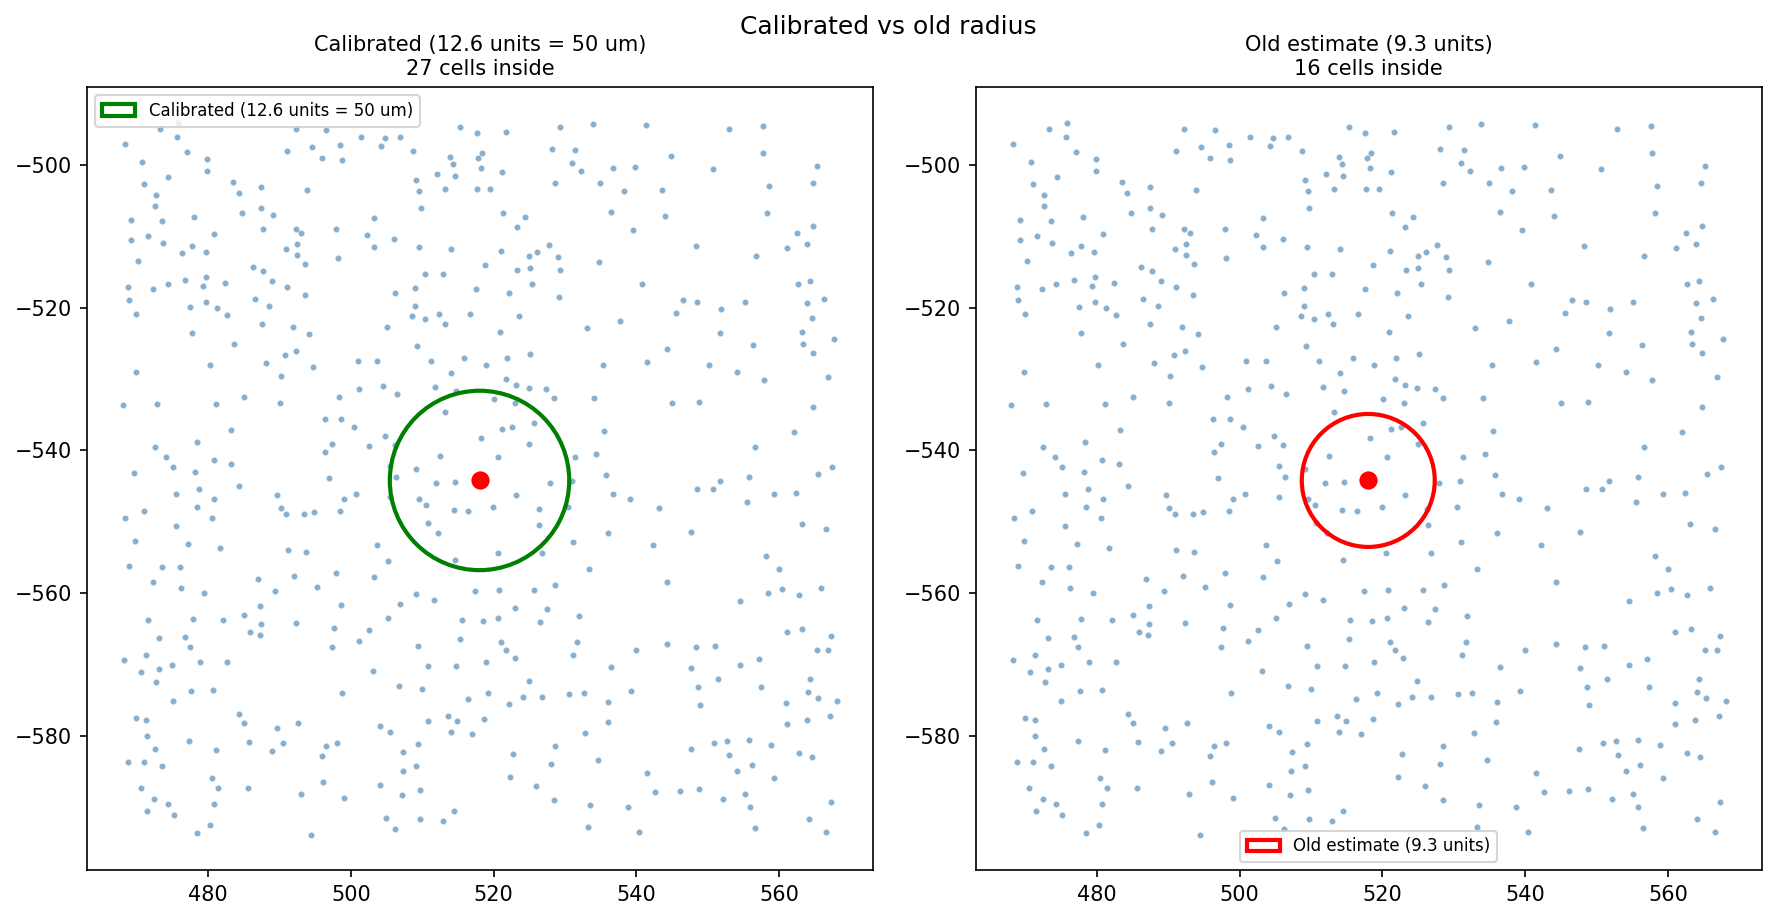

In [22]:
import matplotlib.patches as patches

center_approx = np.median(spatial, axis=0)
anchor_idx = int(np.argmin(np.linalg.norm(spatial - center_approx, axis=1)))
cx, cy = spatial[anchor_idx]
window = RADIUS_CALIBRATED * 4
mask = (
    (spatial[:, 0] > cx - window) & (spatial[:, 0] < cx + window) &
    (spatial[:, 1] > cy - window) & (spatial[:, 1] < cy + window)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, radius, label, color in [
    (axes[0], RADIUS_CALIBRATED, f"Calibrated ({RADIUS_CALIBRATED:.1f} units = {TARGET_RADIUS_UM:.0f} um)", "green"),
    (axes[1], radius_old,        f"Old estimate ({radius_old:.1f} units)", "red"),
]:
    ax.scatter(spatial[mask, 0], spatial[mask, 1], s=4, c="steelblue", alpha=0.5)
    ax.scatter([cx], [cy], s=60, c="red", zorder=5)
    circle = patches.Circle((cx, cy), radius=radius,
                             fill=False, edgecolor=color, linewidth=2, label=label)
    ax.add_patch(circle)
    n_inside = (np.linalg.norm(spatial - spatial[anchor_idx], axis=1) < radius).sum() - 1
    ax.set_aspect("equal")
    ax.set_title(f"{label}\n{n_inside} cells inside", fontsize=10)
    ax.legend(fontsize=8)
plt.suptitle("Calibrated vs old radius", fontsize=12)
plt.tight_layout()
plt.show()

## Step 6 - full neighbour-count distribution at calibrated radius

RADIUS_UNITS = 12.57  (calibrated = 50.0 um, target median=32)
UM_PER_UNIT  = 3.9781

Neighbour counts (full dataset, 2D):
  median=32  mean=35.8  p10=20  p90=57
  target median = 32  -> MATCH
  cells with <3 neighbours: 13 (0.0%)


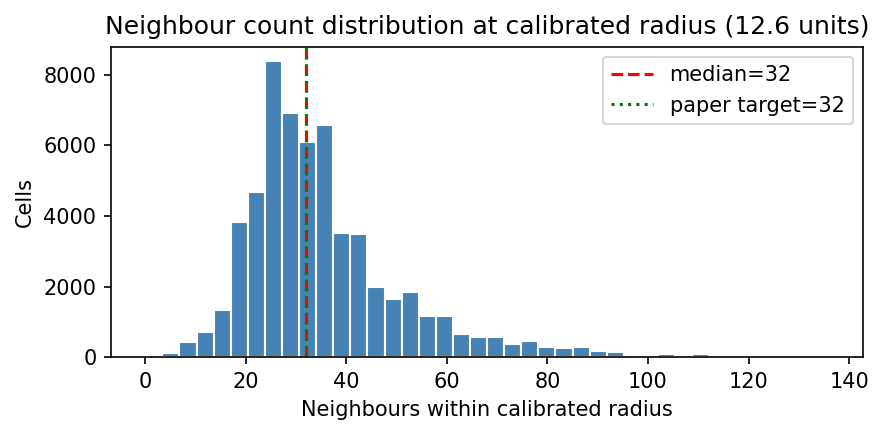

In [23]:
RADIUS_UNITS = RADIUS_CALIBRATED
print(f"RADIUS_UNITS = {RADIUS_UNITS:.2f}  (calibrated = {TARGET_RADIUS_UM} um, target median={TARGET_NEIGHBORS})")
print(f"UM_PER_UNIT  = {UM_PER_UNIT_calibrated:.4f}")

nn_r = NearestNeighbors(radius=RADIUS_UNITS).fit(spatial)
neighbor_counts = np.array([
    len(idx) - 1
    for idx in nn_r.radius_neighbors(spatial, return_distance=False)
])

print(f"\nNeighbour counts (full dataset, 2D):")
print(f"  median={np.median(neighbor_counts):.0f}  mean={neighbor_counts.mean():.1f}  "
      f"p10={np.percentile(neighbor_counts, 10):.0f}  p90={np.percentile(neighbor_counts, 90):.0f}")
status = "MATCH" if abs(np.median(neighbor_counts) - TARGET_NEIGHBORS) <= 2 else "CHECK"
print(f"  target median = {TARGET_NEIGHBORS}  -> {status}")
print(f"  cells with <3 neighbours: {(neighbor_counts < 3).sum()} ({100*(neighbor_counts < 3).mean():.1f}%)")

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(neighbor_counts, bins=40, color="steelblue", edgecolor="white")
ax.axvline(np.median(neighbor_counts), color="red", linestyle="--",
           label=f"median={np.median(neighbor_counts):.0f}")
ax.axvline(TARGET_NEIGHBORS, color="green", linestyle=":",
           label=f"paper target={TARGET_NEIGHBORS}")
ax.set_xlabel("Neighbours within calibrated radius")
ax.set_ylabel("Cells")
ax.set_title(f"Neighbour count distribution at calibrated radius ({RADIUS_UNITS:.1f} units)")
ax.legend()
plt.tight_layout()
plt.show()

## Step 7 - radius-based COVET

Use the calibrated radius for COVET neighbourhood computation.

In [24]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

def covet_spatial_knn_radius(ad, radius_units):
    """Spatial neighbors within radius_units. Returns list of index arrays (excl. self)."""
    spatial = ad.obsm['spatial'][:, :2].astype(np.float32)
    nn = NearestNeighbors(radius=radius_units).fit(spatial)
    neighbors = nn.radius_neighbors(spatial, return_distance=False)
    return [nbrs[nbrs != i] for i, nbrs in enumerate(neighbors)]


def covet_cov_flat_radius(ad, neighbors, n_pcs):
    """Flattened upper-triangle covariance of neighbour PCA, variable neighbourhood size.

    Cells with fewer than 2 neighbours get a zero vector (not enough for covariance).
    """
    X_pca = ad.obsm['X_pca'][:, :n_pcs]
    n = len(ad)
    d = n_pcs * (n_pcs + 1) // 2
    cov_flat = np.zeros((n, d), dtype=np.float32)
    ti, tj = np.triu_indices(n_pcs)

    for i, idx in enumerate(neighbors):
        if len(idx) < 2:
            continue
        X_nbr = X_pca[idx]
        X_nbr = X_nbr - X_nbr.mean(0)
        cov = (X_nbr.T @ X_nbr) / (len(idx) - 1)
        cov_flat[i] = cov[ti, tj]

    return cov_flat


def compute_covet_features_radius(ad, radius_units, n_pcs=25,
                                  alpha=1.0, n_comps=None, obsm_key='X_covet_radius'):
    """COVET with 50 µm radius neighbourhood instead of fixed-k kNN.

    Args:
        ad:           AnnData with obsm['spatial'] and obsm['X_pca']
        radius_units: 50 µm converted to coordinate units
        n_pcs:        PCA dims used as input to covariance
        alpha:        variance fraction from covariance side (1.0 = covet-only)
        n_comps:      PCA components from flattened covariance (None = auto)
        obsm_key:     where to store the result
    """
    from interpretable_ssl.augmenters.graph_generator import _covet_apply

    print(f'[covet_radius] radius={radius_units:.1f} units  n_pcs={n_pcs}  alpha={alpha}')
    neighbors = covet_spatial_knn_radius(ad, radius_units)

    counts = np.array([len(n) for n in neighbors])
    print(f'[covet_radius] neighbour counts: median={np.median(counts):.0f}  '
          f'min={counts.min()}  max={counts.max()}  '
          f'cells_with_<2={( counts < 2).sum()}')

    cov_flat = covet_cov_flat_radius(ad, neighbors, n_pcs)
    n_comps_used, n_cov_dims = _covet_apply(ad, cov_flat, n_comps, alpha, obsm_key)
    print(f'[covet_radius] stored in obsm["{obsm_key}"]  shape={ad.obsm[obsm_key].shape}')
    return neighbors

In [25]:
if "X_pca" not in ad.obsm:
    sc.pp.highly_variable_genes(ad, n_top_genes=2000)
    sc.tl.pca(ad, n_comps=50, use_highly_variable=True)

neighbors = compute_covet_features_radius(
    ad,
    radius_units=RADIUS_UNITS,
    n_pcs=25,
    alpha=1.0,
    obsm_key="X_covet_radius",
)

[covet_radius] radius=12.6 units  n_pcs=25  alpha=1.0
[covet_radius] neighbour counts: median=32  min=0  max=136  cells_with_<2=6
[covet_radius] stored in obsm["X_covet_radius"]  shape=(58423, 50)


## Step 8 - compare radius-COVET vs fixed-k COVET (k=35)

k=35 is the paper-grounded default in `compute_covet_features`.
High per-dimension correlation means both capture the same ~32-cell neighbourhood.

covet: k=35  n_pcs=25  n_comps=50  alpha=1.0 (covet-only)  cov_dims=325→50
Per-dimension correlation (kNN k=35 vs calibrated radius 12.6 units):
  mean=0.413  median=0.752  min=-0.892  max=0.962
  (high = both capture the same ~32-cell neighbourhood)


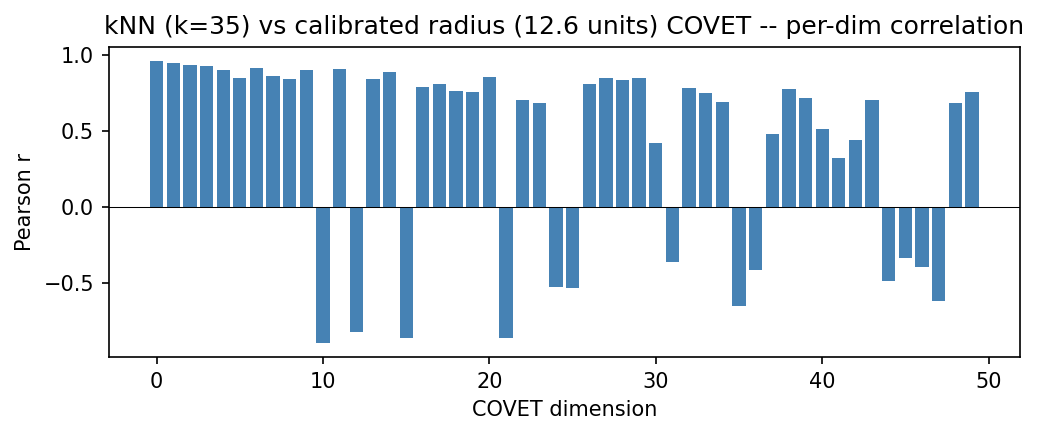


=== Calibration summary ===
  Calibrated radius  = 12.57 coordinate units
  Physical radius    = 50.0 um
  Scale              = 3.9781 um/unit
  Implied cell diam  = 8.9 um  (expected 10-15 um)
  Median neighbours  = 32  (paper target 32)
  k=35 vs radius corr: mean=0.413


In [26]:
from interpretable_ssl.augmenters.graph_generator import compute_covet_features

compute_covet_features(ad, k=35, n_pcs=25, alpha=1.0, obsm_key="X_covet_k35")

X_k35    = ad.obsm["X_covet_k35"]
X_radius = ad.obsm["X_covet_radius"]

n_dims = min(X_k35.shape[1], X_radius.shape[1])
corrs = [
    float(np.corrcoef(X_k35[:, d], X_radius[:, d])[0, 1])
    for d in range(n_dims)
]
print(f"Per-dimension correlation (kNN k=35 vs calibrated radius {RADIUS_UNITS:.1f} units):")
print(f"  mean={np.mean(corrs):.3f}  median={np.median(corrs):.3f}  "
      f"min={np.min(corrs):.3f}  max={np.max(corrs):.3f}")
print("  (high = both capture the same ~32-cell neighbourhood)")

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(n_dims), corrs, color="steelblue")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("COVET dimension")
ax.set_ylabel("Pearson r")
ax.set_title(f"kNN (k=35) vs calibrated radius ({RADIUS_UNITS:.1f} units) COVET -- per-dim correlation")
plt.tight_layout()
plt.show()

print(f"\n=== Calibration summary ===")
print(f"  Calibrated radius  = {RADIUS_UNITS:.2f} coordinate units")
print(f"  Physical radius    = {TARGET_RADIUS_UM} um")
print(f"  Scale              = {UM_PER_UNIT_calibrated:.4f} um/unit")
print(f"  Implied cell diam  = {implied_cell_diameter_um:.1f} um  (expected 10-15 um)")
print(f"  Median neighbours  = {int(np.median(neighbor_counts))}  (paper target {TARGET_NEIGHBORS})")
print(f"  k=35 vs radius corr: mean={np.mean(corrs):.3f}")